## Methodological rationale

This notebook follows a distributional forecasting perspective rather than a point-only forecasting perspective. Forecasting literature emphasizes that point forecasts are incomplete without prediction intervals, because intervals communicate the uncertainty associated with future outcomes. Quantile-based methods are particularly attractive when residual distributions are asymmetric or when variance changes with context.

# Quantile Regression for Bus Delay Uncertainty Estimation

This notebook develops a route-level quantile regression (QR) framework to estimate uncertainty around bus delay predictions for the B41 line. The goal is not only to predict expected delay, but to produce calibrated prediction intervals that reflect how uncertainty changes across time, location, and operating conditions.

Our broader project combines a point forecasting model and an interval forecasting layer. In this notebook, the point forecast is temporarily represented by a placeholder or baseline proxy while we wait for the final LSTM output. The QR component is therefore developed independently so that its data pipeline, feature set, interval logic, and evaluation procedure are already validated and ready to integrate with the LSTM predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster

In [2]:
df = pd.read_csv('nyc_bus_cleaned.csv')

## Route-specific dataset construction

We begin by isolating the B41 route and restricting the analysis to a consistent time window. This route-level approach is intentional: bus delay behavior is highly context-dependent, and pooling routes with different stop spacing, operational patterns, and passenger demand can blur the delay structure we want the model to learn.

Working on a single route also makes the spatial and temporal patterns easier to interpret. It allows us to reconstruct stop-level geography, examine route-specific delay behavior, and train an uncertainty model that is tied to the actual operational conditions of one line rather than an average over many heterogeneous services.

In [3]:
df_B41 = df[df['PublishedLineName'] == 'B41'].copy()

In [4]:
df_B41['RecordedAtTime'] = pd.to_datetime(df_B41['RecordedAtTime'])
df_B41['ExpectedArrivalTime'] = pd.to_datetime(df_B41['ExpectedArrivalTime'])
df_B41['Scheduled_dt'] = pd.to_datetime(df_B41['Scheduled_dt'])

In [5]:
df_B41 = df_B41[df_B41['Scheduled_dt'].dt.month == 6]
print(f"Rows after June filter: {len(df_B41):,}")
print(f"Date range: {df_B41['Scheduled_dt'].min()} → {df_B41['Scheduled_dt'].max()}")

Rows after June filter: 91,771
Date range: 2017-06-01 00:00:00 → 2017-06-30 23:54:00


In [6]:
print(f"Total B41 rows: {len(df_B41):,}")
print(f"Directions: {df_B41['DirectionRef'].unique()}")
print(f"Unique next stops: {df_B41['NextStopPointName'].nunique()}")
df_B41.head(3)

Total B41 rows: 91,771
Directions: [1. 0.]
Unique next stops: 85


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime,Scheduled_dt,delay_minutes
388,2017-06-01 00:03:31,1.0,B41,CADMAN PLAZA WEST/JOHNSON ST,40.695534,-73.990829,KINGS PLAZA via FLATBSH,40.609211,-73.921516,NYCT_4602,40.649097,-73.958392,FLATBUSH AV/ALBEMARLE RD,< 1 stop away,215.0,2017-06-01 00:04:41,00:05:22,2017-06-01 00:05:22,-0.683333
439,2017-06-01 00:03:42,0.0,B41,FLATBUSH AV/KINGS PLAZA,40.609253,-73.921539,DNTWN BKLYN CADMAN PLZ via FLATBSH,40.695408,-73.990784,NYCT_4621,40.692423,-73.990166,JORALEMON ST/COURT ST,approaching,46.0,2017-06-01 00:03:57,00:03:31,2017-06-01 00:03:31,0.433333
622,2017-06-01 00:03:36,0.0,B41,FLATBUSH AV/KINGS PLAZA,40.609253,-73.921539,DNTWN BKLYN CADMAN PLZ via FLATBSH,40.695408,-73.990784,NYCT_4595,40.632267,-73.947073,FLATBUSH AV/NOSTRAND AV,approaching,68.0,2017-06-01 00:03:56,00:00:00,2017-06-01 00:00:00,3.933333


## Spatial reconstruction of stop locations

A key part of this workflow is enriching the operational data with geographic information. Because exact stop coordinates are not directly available for every approaching-stop record, we estimate representative stop locations using the median vehicle position for observations associated with each next stop.

This step is important for two reasons. First, location along the route is a strong determinant of delay propagation, since late-running vehicles often accumulate or recover delay depending on where they are in the corridor. Second, spatial features help the model distinguish between uncertainty near terminals, mid-route segments, and congested stop clusters.

In [7]:
# Estimate stop coordinates using median vehicle location
# Each row = a bus reporting it is approaching NextStopPointName
# Median of VehicleLocation gives a robust estimate of the stop position

stop_coords = (
    df_B41
    .groupby(['PublishedLineName', 'DirectionRef', 'NextStopPointName'])
    .agg(
        stop_lat=('VehicleLocation.Latitude',  'median'),
        stop_lon=('VehicleLocation.Longitude', 'median'),
        obs     =('VehicleLocation.Latitude',  'count')
    )
    .reset_index()
    .rename(columns={'NextStopPointName': 'stop_key'})
)

print(f"Stop coordinate table shape: {stop_coords.shape}")
print(f"Stops per direction:")
print(stop_coords.groupby('DirectionRef')['stop_key'].count())
stop_coords.head(10)

Stop coordinate table shape: (103, 6)
Stops per direction:
DirectionRef
0.0    51
1.0    52
Name: stop_key, dtype: int64


,PublishedLineName,DirectionRef,stop_key,stop_lat,stop_lon,obs
0,B41,0.0,AV N/E 46 ST,40.618791,-73.929455,180
1,B41,0.0,AV N/E 48 ST,40.618902,-73.927686,119
2,B41,0.0,AV N/E 53 ST,40.619148,-73.923701,182
3,B41,0.0,AV N/E 55 ST,40.619279,-73.921577,189
4,B41,0.0,AV N/E 57 ST,40.619419,-73.919304,327
5,B41,0.0,AV N/UTICA AV,40.618973,-73.926504,211
6,B41,0.0,CADMAN PLZ W/MONTAGUE ST,40.693387,-73.990570,1382
7,B41,0.0,FLATBUSH AV/ATLANTIC AV,40.683600,-73.977115,2231
8,B41,0.0,FLATBUSH AV/AV D,40.639415,-73.954563,664
9,B41,0.0,FLATBUSH AV/AV I,40.629007,-73.943624,324


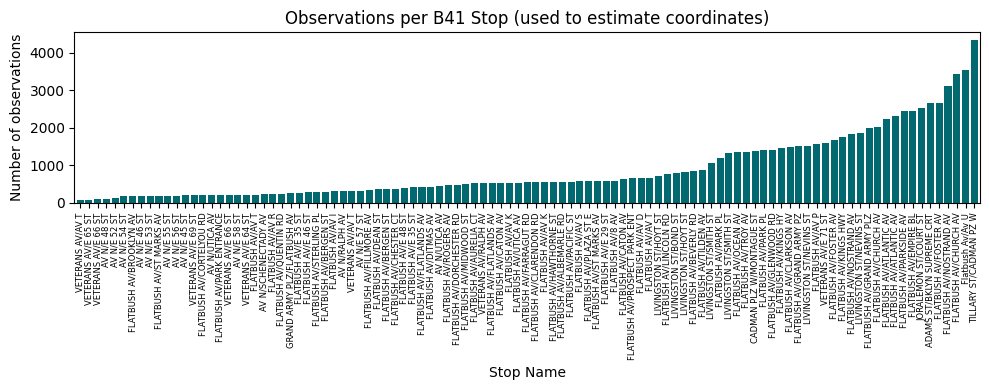


Stops with < 10 observations (potentially unreliable):
Empty DataFrame
Columns: [stop_key, DirectionRef, obs]
Index: []


In [8]:
# Sanity check: how many observations back each stop estimate?
# Low obs count = unreliable median estimate

fig, ax = plt.subplots(figsize=(10, 4))
stop_coords.sort_values('obs').plot.bar(
    x='stop_key', y='obs', ax=ax, legend=False, color='#01696f', width=0.8
)
ax.set_title('Observations per B41 Stop (used to estimate coordinates)')
ax.set_xlabel('Stop Name')
ax.set_ylabel('Number of observations')
ax.tick_params(axis='x', labelsize=6, rotation=90)
plt.tight_layout()
plt.savefig('fig_stop_obs_count.png', dpi=150)
plt.show()

# Flag stops with very few observations
low_obs = stop_coords[stop_coords['obs'] < 10]
print(f"\nStops with < 10 observations (potentially unreliable):")
print(low_obs[['stop_key','DirectionRef','obs']])

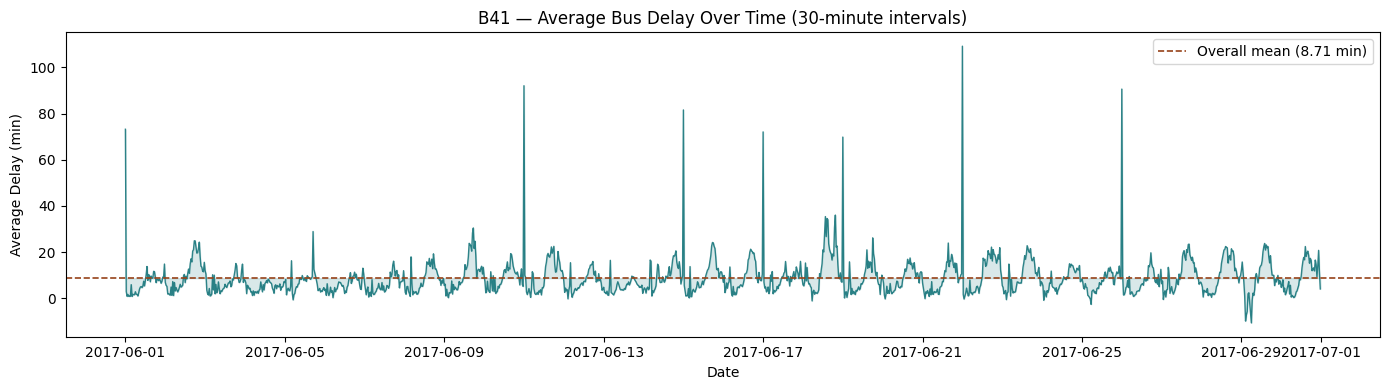

In [9]:
# Time series plot of average delay over time
delay_ts = (
    df_B41
    .set_index('Scheduled_dt')
    .resample('30min')['delay_minutes']
    .mean()
    .dropna()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(delay_ts.index, delay_ts.values,
        color='#01696f', lw=1, alpha=0.8)
ax.axhline(delay_ts.mean(), color='#964219', lw=1.2, ls='--',
           label=f'Overall mean ({delay_ts.mean():.2f} min)')
ax.fill_between(delay_ts.index, delay_ts.values,
                delay_ts.mean(), alpha=0.15, color='#01696f')
ax.set(xlabel='Date', ylabel='Average Delay (min)',
       title='B41 — Average Bus Delay Over Time (30-minute intervals)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_02_delay_timeseries.png', dpi=150)
plt.show()

In [10]:
# Add exact Origin and Destination coordinates
# These are known precisely from the dataset — no need to estimate

origins = (
    df_B41[['PublishedLineName', 'DirectionRef', 'OriginName', 'OriginLat', 'OriginLong']]
    .drop_duplicates()
    .rename(columns={'OriginName':'stop_key','OriginLat':'stop_lat','OriginLong':'stop_lon'})
    .assign(obs=np.nan, stop_type='origin')
)

destinations = (
    df_B41[['PublishedLineName', 'DirectionRef', 'DestinationName', 'DestinationLat', 'DestinationLong']]
    .drop_duplicates()
    .rename(columns={'DestinationName':'stop_key','DestinationLat':'stop_lat','DestinationLong':'stop_lon'})
    .assign(obs=np.nan, stop_type='destination')
)

stop_coords['stop_type'] = 'intermediate'

# Combine all stops
all_stops = pd.concat([origins, destinations, stop_coords], ignore_index=True)

print(f"Total stops (origin + intermediate + destination): {len(all_stops)}")
print(all_stops['stop_type'].value_counts())
all_stops.head()

Total stops (origin + intermediate + destination): 122
stop_type
intermediate    103
destination      10
origin            9
Name: count, dtype: int64


,PublishedLineName,DirectionRef,stop_key,stop_lat,stop_lon,obs,stop_type
0,B41,1.0,CADMAN PLAZA WEST/JOHNSON ST,40.695534,-73.990829,NaN,origin
1,B41,0.0,FLATBUSH AV/KINGS PLAZA,40.609253,-73.921539,NaN,origin
2,B41,0.0,E 70 ST/VETERANS AV,40.619934,-73.908707,NaN,origin
3,B41,1.0,FLATBUSH AV/OCEAN AV,40.662643,-73.962143,NaN,origin
4,B41,0.0,FLATBUSH AV/TROY AV,40.619526,-73.933342,NaN,origin


In [11]:
# Interactive map of B41 stop locations
# Color: green = origin, red = destination, blue = intermediate

color_map = {'origin': 'green', 'destination': 'red', 'intermediate': 'blue'}

m = folium.Map(
    location=[all_stops['stop_lat'].median(), all_stops['stop_lon'].median()],
    zoom_start=13
)

for _, row in all_stops.iterrows():
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=5,
        color=color_map.get(row['stop_type'], 'blue'),
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>{row['stop_key']}</b><br>"
            f"Type: {row['stop_type']}<br>"
            f"Dir: {row['DirectionRef']}<br>"
            f"Obs: {row['obs']}",
            max_width=200
        )
    ).add_to(m)

m.save('b41_stop_map.html')
print("Map saved as b41_stop_map.html — open in browser to inspect")
m   # displays inline in Jupyter

Map saved as b41_stop_map.html — open in browser to inspect


In [12]:
# Save the final stop coordinates table
all_stops.to_csv('b41_stop_coords.csv', index=False)
print("Saved: b41_stop_coords.csv")
print(all_stops.shape)
all_stops.tail()

Saved: b41_stop_coords.csv
(122, 7)


,PublishedLineName,DirectionRef,stop_key,stop_lat,stop_lon,obs,stop_type
117,B41,1.0,VETERANS AV/AV T,40.619847,-73.912226,80.0,intermediate
118,B41,1.0,VETERANS AV/E 64 ST,40.619622,-73.916117,218.0,intermediate
119,B41,1.0,VETERANS AV/E 66 ST,40.619751,-73.913914,100.0,intermediate
120,B41,1.0,VETERANS AV/E 69 ST,40.619884,-73.911567,207.0,intermediate
121,B41,1.0,VETERANS AV/E 71 ST,40.620104,-73.908248,1600.0,intermediate


In [13]:
df_B41 = df_B41.merge(
    stop_coords[['stop_key','DirectionRef','stop_lat','stop_lon']],
    left_on=['NextStopPointName','DirectionRef'],
    right_on=['stop_key','DirectionRef'],
    how='left'
)

In [14]:
# Check how many rows got coordinates
matched = df_B41['stop_lat'].notna().sum()
total   = len(df_B41)
print(f"Matched: {matched:,} / {total:,} rows ({matched/total*100:.1f}%)")
df_B41[['NextStopPointName', 'stop_lat', 'stop_lon', 'delay_minutes']].head(5)

Matched: 91,771 / 91,771 rows (100.0%)


,NextStopPointName,stop_lat,stop_lon,delay_minutes
0,FLATBUSH AV/ALBEMARLE RD,40.648339,-73.958222,-0.683333
1,JORALEMON ST/COURT ST,40.691279,-73.989000,0.433333
2,FLATBUSH AV/NOSTRAND AV,40.631540,-73.946305,3.933333
3,FLATBUSH AV/8 AV,40.676827,-73.972203,7.700000
4,FLATBUSH AV/FLATLANDS AV,40.621631,-73.935820,8.533333


## Data cleaning and feature engineering

Before modeling, we clean the delay variable and remove extreme operational anomalies that would otherwise dominate the interval estimates. We then engineer explanatory variables that capture both timing and traffic-related structure, including hour of day, day of week, weekend effects, upstream delay, and distance-to-stop information.

These features are chosen to reflect known sources of transit variability. In practice, bus delays are rarely constant across the day: peak periods, stop sequence, and inherited upstream lateness can all change not only the expected delay but also the spread of possible outcomes.

In [15]:
# Parse timestamps, clean delay column
# Remove extreme outliers (operational anomalies: > 60 min late or early)
before = len(df_B41)
df_B41 = df_B41[(df_B41['delay_minutes'] > -60) & (df_B41['delay_minutes'] < 60)]
df_B41 = df_B41.dropna(subset=['delay_minutes', 'stop_lat', 'stop_lon'])
print(f"Rows removed: {before - len(df_B41):,}  |  Remaining: {len(df_B41):,}")
print(df_B41['delay_minutes'].describe())

Rows removed: 561  |  Remaining: 91,210
count    91210.000000
mean         9.523601
std         11.976642
min        -39.800000
25%          1.550000
50%          5.916667
75%         14.000000
max         59.983333
Name: delay_minutes, dtype: float64


In [16]:
# Feature engineering for QR model
# Temporal features from scheduled arrival time
df_B41['hour']        = df_B41['Scheduled_dt'].dt.hour
df_B41['day_of_week'] = df_B41['Scheduled_dt'].dt.dayofweek
df_B41['is_weekend']  = (df_B41['day_of_week'] >= 5).astype(int)
df_B41['is_peak']     = (
    ((df_B41['hour'] >= 7)  & (df_B41['hour'] <= 9)) |
    ((df_B41['hour'] >= 16) & (df_B41['hour'] <= 19))
).astype(int)

# Distance from stop (uncertainty horizon proxy)
df_B41['DistanceFromStop'] = pd.to_numeric(df_B41['DistanceFromStop'], errors='coerce').fillna(0)

# Upstream delay: lag delay within same vehicle trip
df_B41 = df_B41.sort_values(['VehicleRef', 'Scheduled_dt'])
df_B41['upstream_delay'] = (
    df_B41.groupby('VehicleRef')['delay_minutes']
          .shift(1)
          .fillna(0)
)

print("Features created. Sample:")
df_B41[['hour','is_peak','is_weekend','DistanceFromStop',
        'stop_lat','stop_lon','upstream_delay','delay_minutes']].head(5)

Features created. Sample:


,hour,is_peak,is_weekend,DistanceFromStop,stop_lat,stop_lon,upstream_delay,delay_minutes
3570,7,1,0,152.0,40.619715,-73.914518,0.000000,2.500000
3600,7,1,0,23.0,40.619087,-73.933007,2.500000,3.183333
3630,7,1,0,622.0,40.637571,-73.952704,3.183333,2.300000
3660,7,1,0,470.0,40.654444,-73.959620,2.300000,3.116667
3692,7,1,0,34.0,40.662105,-73.961717,3.116667,7.166667


## Exploratory analysis and motivation for quantile regression

The exploratory analysis is used to examine whether delay variability changes across time and space. If the variance of delay is not constant, then a single global error term is unlikely to describe forecast uncertainty well.

This matters because quantile regression is particularly useful when the conditional distribution of the target is asymmetric or heteroscedastic. In forecast evaluation literature, quantiles and prediction intervals are standard tools for representing uncertainty, and interval quality is assessed by both coverage and sharpness rather than point accuracy alone. [page:1][page:2]

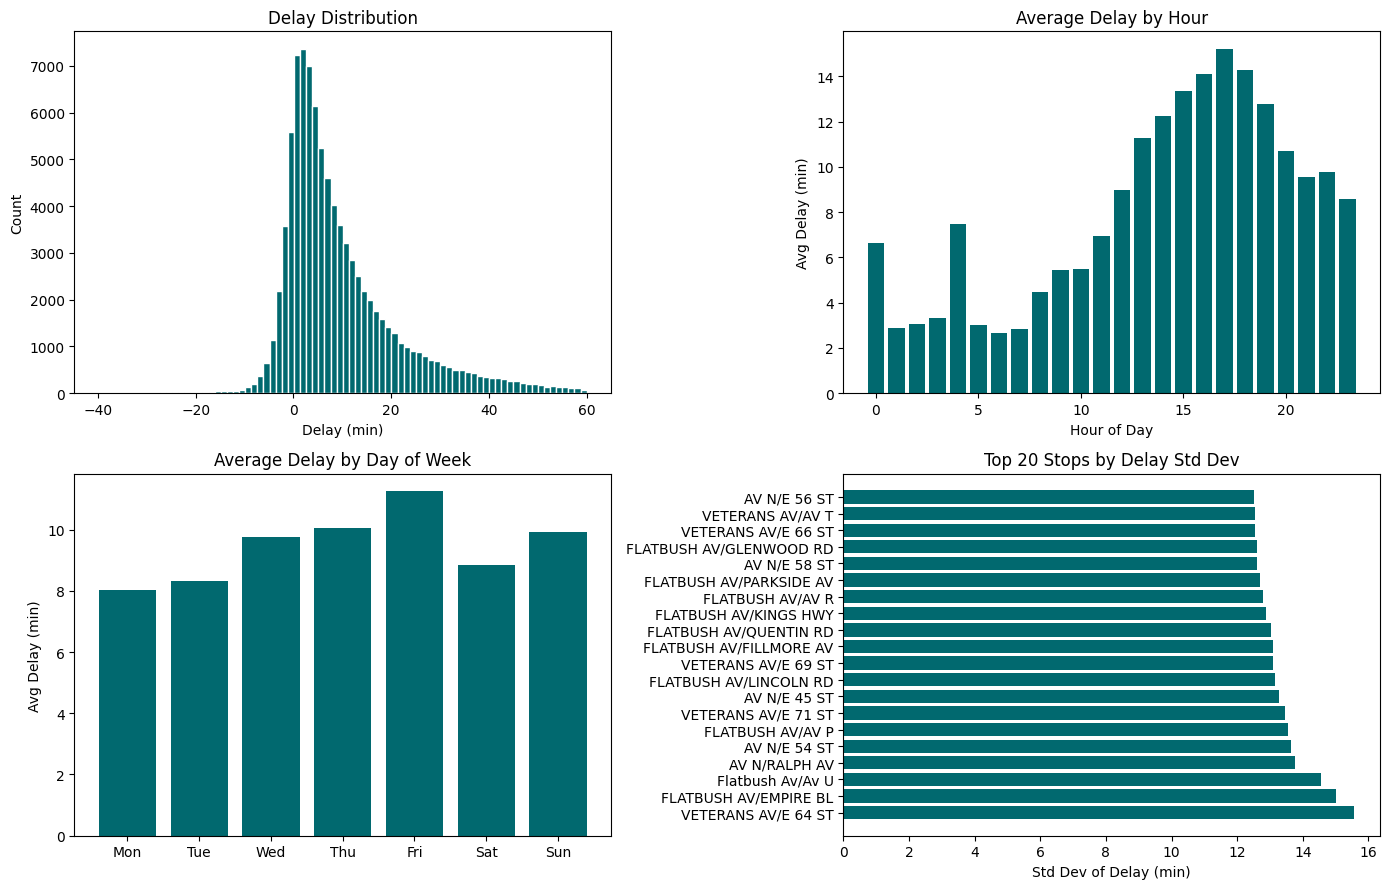

In [17]:
# EDA: key delay patterns across time and stops
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Delay distribution
axes[0,0].hist(df_B41['delay_minutes'], bins=80, color='#01696f', edgecolor='white')
axes[0,0].set(title='Delay Distribution', xlabel='Delay (min)', ylabel='Count')

# 2. Average delay by hour
hourly = df_B41.groupby('hour')['delay_minutes'].mean()
axes[0,1].bar(hourly.index, hourly.values, color='#01696f')
axes[0,1].set(title='Average Delay by Hour', xlabel='Hour of Day', ylabel='Avg Delay (min)')

# 3. Average delay by day of week
daily = df_B41.groupby('day_of_week')['delay_minutes'].mean()
axes[1,0].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], daily.values, color='#01696f')
axes[1,0].set(title='Average Delay by Day of Week', ylabel='Avg Delay (min)')

# 4. Delay variance by stop (heteroscedasticity visual)
stop_var = (df_B41.groupby('NextStopPointName')['delay_minutes']
                  .std()
                  .sort_values(ascending=False)
                  .head(20))
axes[1,1].barh(stop_var.index, stop_var.values, color='#01696f')
axes[1,1].set(title='Top 20 Stops by Delay Std Dev',
              xlabel='Std Dev of Delay (min)')

plt.tight_layout()
plt.savefig('fig_02_eda_delay.png', dpi=150)
plt.show()

## Formal test of non-constant variance

To support the use of quantile regression empirically, we run a Breusch–Pagan test on residuals from a temporary OLS specification. The purpose is not to use OLS as the final model, but to verify whether residual variance changes systematically with the predictors.

If heteroscedasticity is present, then uncertainty is condition-dependent rather than constant. This provides a strong methodological argument for moving from mean-based regression toward quantile-based modeling of the residual distribution.

In [18]:
# Test for heteroscedasticity before applying QR
# We use a temporary OLS model; the residuals are what we test
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Temporary simple OLS: predict delay from key features
bp_features = ['DistanceFromStop', 'is_peak', 'upstream_delay', 'hour']
X_bp = sm.add_constant(df_B41[bp_features].dropna())
y_bp = df_B41.loc[X_bp.index, 'delay_minutes']

ols_temp = sm.OLS(y_bp, X_bp).fit()
bp_stat, bp_p, _, _ = het_breuschpagan(ols_temp.resid, X_bp)

print(f"Breusch-Pagan statistic : {bp_stat:.3f}")
print(f"p-value                 : {bp_p:.6f}")

if bp_p < 0.05:
    print("\n✓ HETEROSCEDASTICITY CONFIRMED (p < 0.05)")
    print("  Variance of delay is NOT constant across conditions.")
    print("  → Quantile Regression is the correct approach.")
else:
    print("\nNo significant heteroscedasticity detected.")

Breusch-Pagan statistic : 8120.456
p-value                 : 0.000000

✓ HETEROSCEDASTICITY CONFIRMED (p < 0.05)
  Variance of delay is NOT constant across conditions.
  → Quantile Regression is the correct approach.


## Residual-based uncertainty modeling around a point forecast

The quantile regression model is designed to learn residual uncertainty around a point prediction source. In the final project workflow, that source will be the LSTM output. For now, we use a temporary proxy so the QR pipeline can be built, stress-tested, and tuned before the final LSTM predictions are delivered.

This modular design separates two tasks: the point model estimates the center of the prediction, while the QR model estimates how far actual outcomes may fall above or below that center under different operating conditions.

In [19]:
# Load external Ridge baseline results for QR calibration
qr_df = pd.read_csv('predictions_ridge_test.csv')

qr_df['timestamp'] = pd.to_datetime(qr_df['timestamp'])

required_cols = ['timestamp', 'horizon', 'horizon_min', 'y_true', 'y_pred', 'residual']
missing = [c for c in required_cols if c not in qr_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

qr_df = qr_df.sort_values(['timestamp', 'horizon']).reset_index(drop=True)

print(qr_df.head())
print(qr_df.shape)
print(qr_df.dtypes)

   timestamp  horizon  horizon_min  y_true  y_pred  residual
0 2017-12-02        1           30  5.5280  7.6419   -2.1139
1 2017-12-02        2           60  4.4315  6.3799   -1.9484
2 2017-12-02        3           90  2.8500  5.1788   -2.3288
3 2017-12-02        4          120  1.4241  4.2745   -2.8504
4 2017-12-02        5          150  1.3431  3.4135   -2.0704
(16836, 6)
timestamp      datetime64[ns]
horizon                 int64
horizon_min             int64
y_true                float64
y_pred                float64
residual              float64
dtype: object


In [20]:
# Cell 13b — Time-based feature engineering from the forecast timestamp
qr_df['hour'] = qr_df['timestamp'].dt.hour
qr_df['day_of_week'] = qr_df['timestamp'].dt.dayofweek
qr_df['is_weekend'] = (qr_df['day_of_week'] >= 5).astype(int)
qr_df['is_peak'] = qr_df['hour'].isin([7, 8, 9, 15, 16, 17]).astype(int)

# Cyclical encoding for hour-of-day
qr_df['hour_sin'] = np.sin(2 * np.pi * qr_df['hour'] / 24)
qr_df['hour_cos'] = np.cos(2 * np.pi * qr_df['hour'] / 24)

print(qr_df[['timestamp', 'horizon', 'horizon_min', 'hour', 'is_peak', 'is_weekend']].head())

   timestamp  horizon  horizon_min  hour  is_peak  is_weekend
0 2017-12-02        1           30     0        0           1
1 2017-12-02        2           60     0        0           1
2 2017-12-02        3           90     0        0           1
3 2017-12-02        4          120     0        0           1
4 2017-12-02        5          150     0        0           1


In [21]:
# Cell 13c — Verify residual consistency
qr_df['residual_check'] = qr_df['y_true'] - qr_df['y_pred']
max_diff = (qr_df['residual'] - qr_df['residual_check']).abs().max()

print(f"Max absolute difference between provided residual and recomputed residual: {max_diff:.10f}")

if max_diff > 1e-8:
    print("Warning: provided residual does not exactly match y_true - y_pred")
else:
    print("Residual column is consistent.")

Max absolute difference between provided residual and recomputed residual: 0.0001000000


In [22]:
# Cell 14 — Build feature matrix and chronological split
feature_cols = [
    'y_pred',
    'horizon',
    'horizon_min',
    'hour_sin',
    'hour_cos',
    'is_peak',
    'is_weekend',
]

model_df = qr_df[feature_cols + ['residual', 'y_true', 'timestamp']].dropna().copy()
model_df = model_df.sort_values(['timestamp', 'horizon']).reset_index(drop=True)

cutoff = int(len(model_df) * 0.8)

train_df = model_df.iloc[:cutoff].copy()
test_df  = model_df.iloc[cutoff:].copy()

X_train = train_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()
y_train = train_df['residual'].copy()
y_test  = test_df['residual'].copy()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train period: {train_df['timestamp'].min()} → {train_df['timestamp'].max()}")
print(f"Test period:  {test_df['timestamp'].min()} → {test_df['timestamp'].max()}")

Train: (13468, 7) | Test: (3368, 7)
Train period: 2017-12-02 00:00:00 → 2017-12-25 18:00:00
Test period:  2017-12-25 18:00:00 → 2017-12-31 17:30:00


## Training conditional quantile models

We fit separate quantile regression models for several target quantiles of the residual distribution. This allows us to estimate lower and upper error bounds directly instead of assuming symmetric Gaussian errors.

This choice aligns with standard distributional forecasting practice, where quantile forecasts are evaluated using quantile or pinball loss, and prediction intervals are derived from lower and upper quantiles. Quantile-based methods are especially appropriate when forecast errors are skewed or have non-constant variance.

In [23]:
# Train one QR model per target quantile (pinball loss)
# Cell 15 — Train one QR model per target quantile
import statsmodels.formula.api as smf

train_qr = train_df.copy()

QUANTILES = [0.05, 0.10, 0.25, 0.75, 0.90, 0.95]

formula = (
    'residual ~ y_pred + horizon + horizon_min + hour_sin + hour_cos + is_peak + is_weekend'
)

qr_models = {}
for q in QUANTILES:
    model = smf.quantreg(formula, data=train_qr).fit(q=q, max_iter=5000)
    qr_models[q] = model
    print(f"Q{int(q*100):02d} | Pseudo-R²: {model.prsquared:.4f}")

print("\nAll quantile models trained.")

Q05 | Pseudo-R²: 0.0970
Q10 | Pseudo-R²: 0.0739
Q25 | Pseudo-R²: 0.0563
Q75 | Pseudo-R²: 0.1016
Q90 | Pseudo-R²: 0.1521
Q95 | Pseudo-R²: 0.1507

All quantile models trained.


## Constructing prediction intervals and evaluating calibration

After estimating the residual quantiles, we convert them into prediction intervals around the point forecast. We then assess interval quality using two complementary metrics: PICP, which measures empirical coverage, and MPIL, which measures average interval width.

This reflects the standard principle that good intervals should be both calibrated and sharp. High coverage alone is not enough if intervals are excessively wide, and narrow intervals are not useful if they miss the realized values too often.

In [24]:
# Cell 16 — Construct prediction intervals and compute PICP / MPIL
test_eval = test_df.copy()

for q in QUANTILES:
    test_eval[f'q{int(q*100):02d}'] = qr_models[q].predict(test_eval)

test_eval['observed'] = test_eval['y_true']

# PI bounds = Ridge point prediction + residual quantile correction
test_eval['pi90_lower'] = test_eval['y_pred'] + test_eval['q05']
test_eval['pi90_upper'] = test_eval['y_pred'] + test_eval['q95']
test_eval['pi80_lower'] = test_eval['y_pred'] + test_eval['q10']
test_eval['pi80_upper'] = test_eval['y_pred'] + test_eval['q90']

def picp(lo, hi, obs):
    return ((obs >= lo) & (obs <= hi)).mean()

def mpil(lo, hi):
    return (hi - lo).mean()

print(f"{'Interval':<10} {'PICP':>8} {'MPIL (min)':>12} {'Status':>8}")
print("-" * 42)

for label, lo, hi in [
    ('80%', 'pi80_lower', 'pi80_upper'),
    ('90%', 'pi90_lower', 'pi90_upper')
]:
    coverage = picp(test_eval[lo], test_eval[hi], test_eval['observed'])
    width = mpil(test_eval[lo], test_eval[hi])
    target = float(label.strip('%')) / 100
    flag = '✓ PASS' if coverage >= target - 0.03 else '✗ FAIL'
    print(f"{label:<10} {coverage:>8.3f} {width:>12.3f} {flag:>8}")

Interval       PICP   MPIL (min)   Status
------------------------------------------
80%           0.740        8.900   ✗ FAIL
90%           0.863       11.865   ✗ FAIL


## Visual interpretation of interval forecasts

The following plot compares predicted interval bands with realized delays. The main question is whether the uncertainty bands expand and contract in a sensible way as the predicted delay level changes.

A useful uncertainty model should not assign the same interval width everywhere. Instead, it should reflect that some operating contexts are more predictable than others, while congested or unstable conditions produce wider and less certain delay ranges.

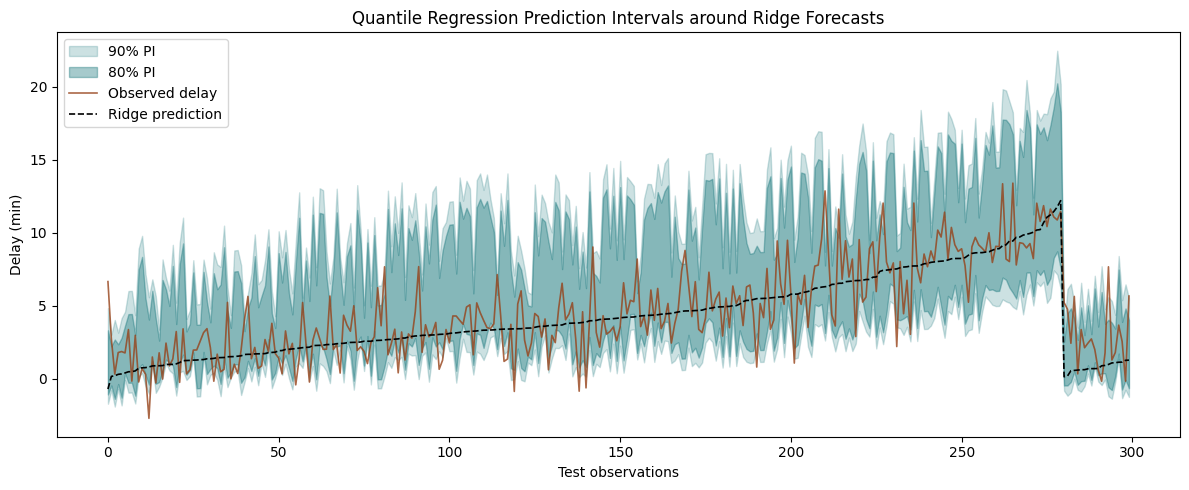

In [25]:
# Cell 17 — Main results plot: PI bands around Ridge prediction
plot_df = test_eval.sort_values(['horizon', 'y_pred']).head(300).copy()
plot_df = plot_df.reset_index(drop=True)

x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x, plot_df['pi90_lower'], plot_df['pi90_upper'],
                alpha=0.20, color='#01696f', label='90% PI')
ax.fill_between(x, plot_df['pi80_lower'], plot_df['pi80_upper'],
                alpha=0.35, color='#01696f', label='80% PI')
ax.plot(x, plot_df['observed'],
        color='#964219', alpha=0.8, lw=1.2, label='Observed delay')
ax.plot(x, plot_df['y_pred'],
        color='black', lw=1.2, ls='--', label='Ridge prediction')

ax.set(
    xlabel='Test observations',
    ylabel='Delay (min)',
    title='Quantile Regression Prediction Intervals around Ridge Forecasts'
)
ax.legend()
plt.tight_layout()
plt.show()

## How uncertainty varies across operational contexts

Finally, we examine how interval width changes across different contexts. This is one of the practical advantages of quantile regression: it allows us to move beyond a single average error estimate and instead identify when the system is stable and when it is volatile.

For transit operations, this is especially valuable because uncertainty itself is informative. A forecast that is slightly less accurate on average but correctly signals high-risk situations can be more useful for planning and decision support than a model that only predicts the mean.

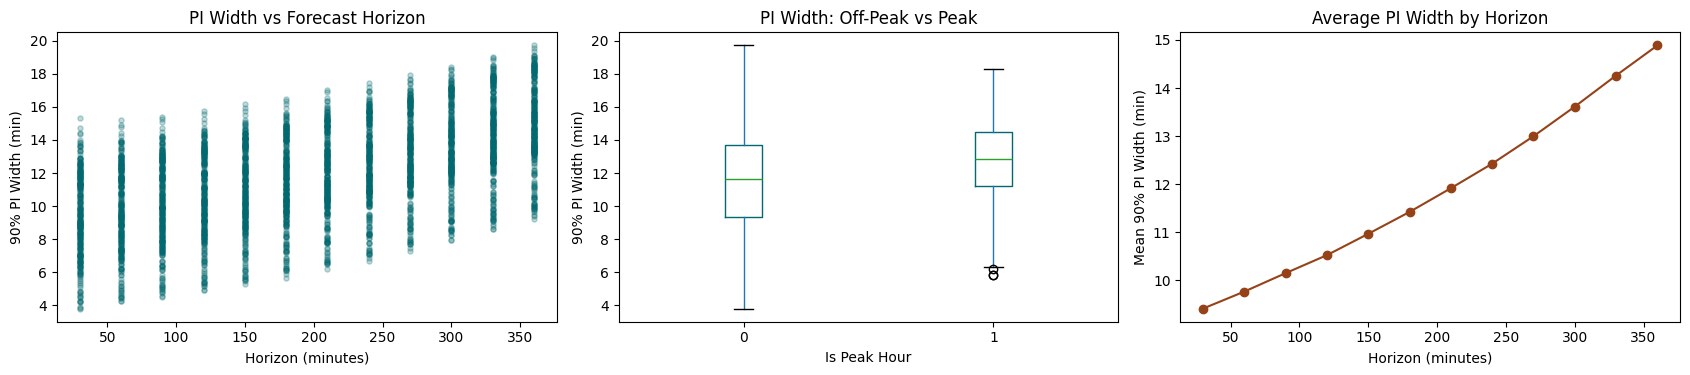

In [26]:
# Cell 18 — Show how uncertainty varies by forecast context
test_eval['pi90_width'] = test_eval['pi90_upper'] - test_eval['pi90_lower']

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# 1. Width vs forecast horizon
axes[0].scatter(test_eval['horizon_min'], test_eval['pi90_width'],
                alpha=0.25, s=14, color='#01696f')
axes[0].set(
    title='PI Width vs Forecast Horizon',
    xlabel='Horizon (minutes)',
    ylabel='90% PI Width (min)'
)

# 2. Width by peak / off-peak
test_eval.boxplot(column='pi90_width', by='is_peak', ax=axes[1], grid=False,
                  boxprops=dict(color='#01696f'))
axes[1].set(
    title='PI Width: Off-Peak (0) vs Peak (1)',
    xlabel='Is Peak Hour',
    ylabel='90% PI Width (min)'
)
plt.sca(axes[1])
plt.title('PI Width: Off-Peak vs Peak')

# 3. Average width by horizon
avg_width = test_eval.groupby('horizon_min')['pi90_width'].mean()
axes[2].plot(avg_width.index, avg_width.values, marker='o', color='#964219')
axes[2].set(
    title='Average PI Width by Horizon',
    xlabel='Horizon (minutes)',
    ylabel='Mean 90% PI Width (min)'
)

plt.suptitle('')
plt.tight_layout()
plt.show()